# Fama-French 3-Factor Model: Explaining Equity Returns

A classic asset-pricing regression: explaining a stock's daily returns using the
Fama-French 3-Factor model.

**The idea:** the Capital Asset Pricing Model (CAPM) says a stock's return is
explained by one thing - how the overall market moved. Fama and French (1993)
showed two more factors meaningfully improve on this:

- **Mkt-RF** - the market's excess return (same idea as CAPM)
- **SMB** ("Small Minus Big") - the tendency for small-company stocks to
  outperform large-company stocks
- **HML** ("High Minus Low") - the tendency for "value" stocks (cheap relative
  to book value) to outperform "growth" stocks

We regress a stock's excess return on these three factors and interpret the
result.

## 1. Imports

In [8]:
import io
import os
import zipfile

import numpy as np
import pandas as pd
import requests
import statsmodels.api as sm
import yfinance as yf
import matplotlib.pyplot as plt

TICKER = "AAPL"
START_DATE = "2015-01-01"


## 2. Load the stock's daily returns

Pulled via `yfinance`. We use simple returns (not log returns) to match the
convention Fama-French use in their own data.

In [9]:
raw = yf.download(TICKER, start=START_DATE, auto_adjust=True, progress=False)
if raw.empty:
    raise ValueError(f"No data returned for ticker '{TICKER}'. Check the symbol.")

close = raw["Close"]
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]  # collapse to a plain Series if needed

stock_returns = close.pct_change().dropna()
stock_returns = stock_returns.rename("stock_return")

stock_returns.head()


Date
2015-01-05   -0.028171
2015-01-06    0.000094
2015-01-07    0.014022
2015-01-08    0.038423
2015-01-09    0.001072
Name: stock_return, dtype: float64

## 3. Load the Fama-French 3-factor data

Pulled directly from Kenneth French's data library at Dartmouth - the standard
public source for this data. This gives us daily Mkt-RF, SMB, HML and the
risk-free rate (RF), all as percentages, which we convert to decimals.

In [10]:
FF_FACTORS_URL = (
    "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
    "F-F_Research_Data_Factors_daily_CSV.zip"
)

resp = requests.get(FF_FACTORS_URL, timeout=30)
resp.raise_for_status()

with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
    csv_name = [n for n in zf.namelist() if n.lower().endswith(".csv")][0]
    with zf.open(csv_name) as f:
        raw_text = f.read().decode("latin-1")

lines = raw_text.splitlines()
header_idx = next(i for i, line in enumerate(lines) if "Mkt-RF" in line)

data_lines = [lines[header_idx]]
for line in lines[header_idx + 1:]:
    first_field = line.split(",")[0].strip()
    # data rows start with an 8-digit date (YYYYMMDD); stop once we hit the
    # annual-data section or trailing notes, which break this pattern
    if first_field.isdigit() and len(first_field) == 8:
        data_lines.append(line)
    elif len(data_lines) > 1:
        break

factors = pd.read_csv(io.StringIO("\n".join(data_lines)))
factors.columns = [c.strip() for c in factors.columns]
factors = factors.rename(columns={factors.columns[0]: "date"})
factors["date"] = pd.to_datetime(factors["date"], format="%Y%m%d")
factors = factors.set_index("date")

for col in ["Mkt-RF", "SMB", "HML", "RF"]:
    factors[col] = pd.to_numeric(factors[col], errors="coerce") / 100.0

factors = factors.dropna()
factors.head()


,Mkt-RF,SMB,HML,RF
date,,,,
1926-07-01,0.0009,-0.0023,-0.0028,0.0001
1926-07-02,0.0045,-0.0034,-0.0003,0.0001
1926-07-06,0.0017,0.0029,-0.0038,0.0001
1926-07-07,0.0009,-0.0062,0.0003,0.0001
1926-07-08,0.0022,-0.0038,0.0018,0.0001


## 4. Merge and compute excess return

`excess_return = stock_return - RF` (the return above the risk-free rate,
which is what the model actually explains).

In [11]:
data = pd.concat([stock_returns, factors], axis=1, join="inner")
data["excess_return"] = data["stock_return"] - data["RF"]
data = data.dropna()

print(f"{len(data)} matched trading days")
data.head()


2910 matched trading days


,stock_return,Mkt-RF,SMB,HML,RF,excess_return
2015-01-05,-0.028171,-0.0184,0.0033,-0.0068,0.0,-0.028171
2015-01-06,0.000094,-0.0103,-0.0080,-0.0029,0.0,0.000094
2015-01-07,0.014022,0.0119,0.0020,-0.0067,0.0,0.014022
2015-01-08,0.038423,0.0181,-0.0011,-0.0029,0.0,0.038423
2015-01-09,0.001072,-0.0085,0.0001,-0.0047,0.0,0.001072


## 5. Fit the 3-factor regression

`Excess Return = alpha + beta_mkt * Mkt-RF + beta_smb * SMB + beta_hml * HML + error`

No lookahead issue here (unlike a forecasting model) - this is an explanatory
regression fit on the whole sample at once, which is the standard way this
model is used in practice and in the original Fama-French papers.

In [12]:
X = data[["Mkt-RF", "SMB", "HML"]]
X = sm.add_constant(X)  # adds the alpha (intercept) term
y = data["excess_return"]

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())


                            OLS Regression Results                            
Dep. Variable:          excess_return   R-squared:                       0.564
Model:                            OLS   Adj. R-squared:                  0.564
Method:                 Least Squares   F-statistic:                     1255.
Date:                Fri, 04 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:25:45   Log-Likelihood:                 8747.1
No. Observations:                2910   AIC:                        -1.749e+04
Df Residuals:                    2906   BIC:                        -1.746e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.625      0.1

## 6. Interpret the coefficients

- **beta_mkt** - how sensitive the stock is to the overall market (close to 1
  = moves with the market; higher = more aggressive than the market)
- **beta_smb** - positive means it behaves more like a small-cap stock;
  negative means more like a large-cap stock
- **beta_hml** - positive means it behaves more like a value stock; negative
  means more like a growth stock
- **alpha** - the return left unexplained by the three factors. In an
  efficient market this should be close to zero; a large, statistically
  significant alpha would be a notable (and rare) finding
- **R-squared** - how much of the stock's return variation the three factors
  explain overall

In [13]:
coef_names = {"const": "Alpha", "Mkt-RF": "Mkt-RF beta",
              "SMB": "SMB beta", "HML": "HML beta"}

results_table = pd.DataFrame({
    "coefficient": [coef_names[name] for name in results.params.index],
    "estimate": results.params.values,
    "p_value": results.pvalues.values,
})
results_table["significant_5pct"] = results_table["p_value"] < 0.05

print(results_table.to_string(index=False))
print(f"\nR-squared: {results.rsquared:.4f}")


coefficient  estimate      p_value  significant_5pct
      Alpha  0.000361 1.043321e-01             False
Mkt-RF beta  1.161302 0.000000e+00              True
   SMB beta -0.288728 2.643054e-16              True
   HML beta -0.342938 1.388433e-40              True

R-squared: 0.5644


## 7. Plot: actual vs fitted returns

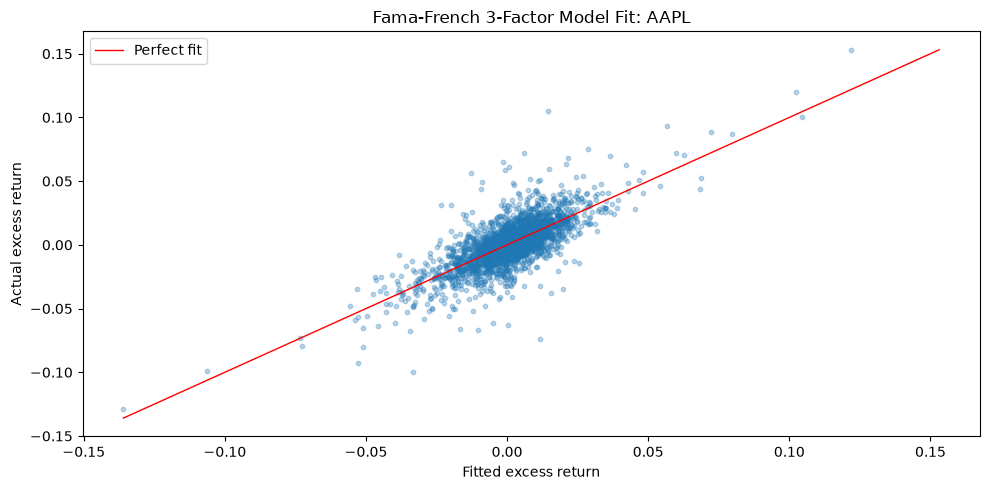

In [14]:
fitted = results.fittedvalues
actual = data["excess_return"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(fitted, actual, alpha=0.3, s=10)
lims = [min(fitted.min(), actual.min()), max(fitted.max(), actual.max())]
ax.plot(lims, lims, color="red", linewidth=1, label="Perfect fit")
ax.set_xlabel("Fitted excess return")
ax.set_ylabel("Actual excess return")
ax.set_title(f"Fama-French 3-Factor Model Fit: {TICKER}")
ax.legend()
fig.tight_layout()
plt.show()


## Limitations

- Single-stock regression on daily data - factor models are more commonly
  applied to diversified portfolios, where idiosyncratic (stock-specific)
  noise averages out. A single stock's daily returns are noisier, so expect
  a lower R-squared than you'd see applying this to a portfolio or index.
- Only covers the original 3 factors - later research (Fama-French 5-Factor,
  momentum) adds more explanatory power.
- Uses daily rather than monthly data; the original Fama-French papers use
  monthly data, which is the more standard convention in academic work.